In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass, field
from typing import List, Tuple, Optional, Dict

In [ ]:
# Configuración reproducible
RNG_SEED = 42
rng = np.random.default_rng(RNG_SEED)

# Parámetros del problema
MIN_HEADWAY = 4.0          # La separación mínima permitida entre aviones, medida en minutos de tiempo de vuelo.
TARGET_HEADWAY = 5.0       # Valor objetivo de separación: los aviones intentan mantener 5 minutos de distancia como buffer de seguridad adicional, si están muy cerca, el avión de atrás baja la velocidad hasta aumentar ese gap a 5.
RADAR_NM = 100.0           # Distancia en millas náuticas (mn) a la que los aviones entran en el radar de Aeroparque (AEP). Cada avión aparece “en la simulación” en este punto inicial.
BACKTRACK_SPEED_KTS = 200.0  # Si un avión no puede mantener la separación (porque debería ir más lento que el mínimo permitido), se sale de la fila y vuela hacia atrás a 200 nudos hasta encontrar un hueco (o salirse del radar a Montevideo, según el caso). Es la velocidad que se usa en ese modo “backtrack”.
NM_PER_MIN_FROM_KTS = 1.0 / 60.0  # conversión nudos -> mn/min

In [3]:
def speed_bounds_for_distance(distance_nm: float) -> Tuple[float, float]:
    """Devuelve (min_kts, max_kts) permitidos según la tabla del enunciado."""
    if distance_nm > 100.0:
        return 300.0, 500.0
    elif distance_nm > 50.0:
        return 250.0, 300.0   # 100..50
    elif distance_nm > 15.0:
        return 200.0, 250.0   # 50..15
    elif distance_nm > 5.0:
        return 150.0, 200.0   # 15..5
    else:
        return 120.0, 150.0   # 5..0

In [12]:
@dataclass
class Aircraft:
    aid: int
    t_spawn: int
    distance_nm: float = RADAR_NM
    speed_kts: float = 0.0
    state: str = "approach"  # approach | backtrack | diverted | landed
    landed_at: Optional[int] = None
    diverted_at: Optional[int] = None
    path_t: List[int] = field(default_factory=list)
    path_d: List[float] = field(default_factory=list)

    def record(self, t: int):
        self.path_t.append(t)
        self.path_d.append(self.distance_nm)

    def eta_minutes(self) -> Optional[float]:
        if self.state != "approach" or self.speed_kts <= 0.0:
            return None
        return self.distance_nm / (self.speed_kts * NM_PER_MIN_FROM_KTS)

In [13]:
class AEPSimulator:
    """Simulación Monte Carlo de arribos y aproximación a AEP.

    - Arribos: proceso Bernoulli por minuto con probabilidad λ.
    - Control de separación: si gap temporal < 4 min, seguidor baja 20 kts respecto del líder
      (respetando mínimos del tramo). Si no puede, se va hacia atrás a 200 kts hasta salir del radar.
    - Posición/tiempo: registra trayectoria de cada avión para visualizar.
    """
    def __init__(self, lam: float, T_minutes: int):
        assert 0.0 < lam <= 1.0
        self.lam = lam
        self.T = T_minutes
        self.planes: List[Aircraft] = []
        self.next_id = 1

    def spawn_if_arrival(self, t: int):
        if rng.random() < self.lam:
            _, max_kts = speed_bounds_for_distance(RADAR_NM)
            p = Aircraft(aid=self.next_id, t_spawn=t, distance_nm=RADAR_NM, speed_kts=max_kts, state="approach")
            self.planes.append(p)
            self.next_id += 1

    def step_headway_control(self, t: int):
        # Lista de (ETA absoluta, avión) para los que están en aproximación
        approach = []
        for p in self.planes:
            if p.state == "approach":
                eta = p.eta_minutes()
                if eta is not None:
                    approach.append((t + eta, p))
        approach.sort(key=lambda x: x[0])  # primero el que llega antes

        for i in range(len(approach) - 1):
            eta_lead, lead = approach[i]
            eta_follow, follow = approach[i + 1]
            f_min_kts, f_max_kts = speed_bounds_for_distance(follow.distance_nm)
            gap = eta_follow - eta_lead  # minutos

            if gap < MIN_HEADWAY:
                proposed = min(f_max_kts, max(0.0, lead.speed_kts - 20.0))
                if proposed < f_min_kts:
                    follow.state = "backtrack"
                    follow.speed_kts = BACKTRACK_SPEED_KTS
                else:
                    follow.speed_kts = proposed
            elif gap >= TARGET_HEADWAY:
                follow.speed_kts = f_max_kts
            # Si está entre 4 y 5, mantenemos velocidad para evitar oscilaciones.
    
    def update_positions(self, t: int):
        for p in self.planes:
            if p.state == "approach":
                min_kts, max_kts = speed_bounds_for_distance(p.distance_nm)
                p.speed_kts = max(min(p.speed_kts, max_kts), min_kts)
                p.distance_nm -= p.speed_kts * NM_PER_MIN_FROM_KTS
                if p.distance_nm <= 0.0:
                    p.distance_nm = 0.0
                    p.state = "landed"
                    p.landed_at = t
            elif p.state == "backtrack":
                p.distance_nm += BACKTRACK_SPEED_KTS * NM_PER_MIN_FROM_KTS
                if p.distance_nm >= RADAR_NM + 1e-6:
                    p.state = "diverted"
                    p.diverted_at = t
            p.record(t)

    def run(self) -> Dict[str, int]:
        for t in range(self.T):
            self.spawn_if_arrival(t)
            self.step_headway_control(t)
            self.update_positions(t)
        landed = sum(1 for p in self.planes if p.state == "landed")
        diverted = sum(1 for p in self.planes if p.state == "diverted")
        backtrack = sum(1 for p in self.planes if p.state == "backtrack")
        approach = sum(1 for p in self.planes if p.state == "approach")
        return {
            "spawned": len(self.planes),
            "landed": landed,
            "diverted": diverted,
            "still_backtracking": backtrack,
            "still_approach": approach,
        }


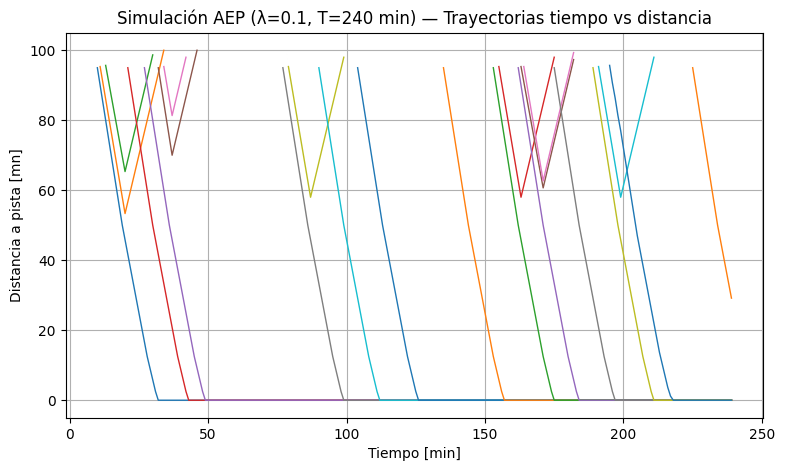

Resumen de la corrida:
- spawned: 23
- landed: 12
- diverted: 10
- still_backtracking: 0
- still_approach: 1


In [14]:
def run_and_plot(lam: float = 0.1, T_minutes: int = 240):
    sim = AEPSimulator(lam=lam, T_minutes=T_minutes)
    summary = sim.run()

    # Visualización: tiempo vs distancia (una línea por avión)
    plt.figure(figsize=(9, 5))
    for p in sim.planes:
        t_arr = np.array(p.path_t)
        d_arr = np.array(p.path_d)
        mask = (d_arr >= 0.0) & (d_arr <= RADAR_NM + 1e-6)
        if mask.any():
            plt.plot(t_arr[mask], d_arr[mask], linewidth=1)
    plt.title(f"Simulación AEP (λ={lam}, T={T_minutes} min) — Trayectorias tiempo vs distancia")
    plt.xlabel("Tiempo [min]")
    plt.ylabel("Distancia a pista [mn]")
    plt.grid(True)
    plt.show()

    print("Resumen de la corrida:")
    for k, v in summary.items():
        print(f"- {k}: {v}")
    return sim, summary

# Parámetros base de demo (podés cambiarlos y re-ejecutar)
_ = run_and_plot(lam=0.1, T_minutes=240)



**Notas**
- Este punto 1 **no** incluye aún re-inserción en la cola tras backtrack (eso se agrega en los puntos 5–6).
- Para simular todo el día (6:00–00:00) usá `T_minutes = 1080`.
- La figura muestra cada avión como una **línea**: pendiente negativa → aproximación; pendiente positiva y salida del gráfico → desvío.